# Yield Curve Module 2

***OIS Curve Construction***

---


## 1. The EUR OIS Discount Curve

The ESTR OIS discount curve is the standard discounting framework for European regulatory
filings, including:

- collateralised EUR derivatives (EMIR)
- IRRBB EVE calculations (EBA/RTS/2022/09)
- IFRS 13 fair value measurements

This notebook covers construction from first principles and the practical data landscape,
using `QuantLib` to handle the curve bootstrap, market conventions, settlement rules,
and day count and calendar details that are baked into the library.

---

### 1.1 Vendor Curves -- Production Standard

In a production environment the OIS curve is sourced and consumed directly from a market data vendor. The curve is pre-bootstrapped, validated intraday, and delivered via API or terminal. 

#### Bloomberg (BVAL / SWPM)
The market standard for most banks and asset managers. The EUR ESTR OIS curve is available under ticker `EUSA` (EUR OIS swap curve) in SWPM. Discount factors can be extracted programmatically via the Bloomberg API (BLPAPI) using the `YCGT0016 Index` curve identifier. Intraday updates, full tenor coverage 1D to 50Y, validated against LCH clearing prices.

#### Refinitiv Eikon / LSEG

Available via the `EUR_ESTR_OIS` curve object in Eikon. Accessible programmatically via the Refinitiv Data Library (RDP API). Similar coverage to Bloomberg, slightly different interpolation methodology. LSEG also publishes FTSE Term ESTR, a forward-looking benchmark derived from OIS quotes sourced from Tradeweb and LCH executed trades.

Both vendors source OIS quotes from inter-dealer brokers (Tradition, ICAP, BGC) and LCH cleared trade data, bootstrap to discount factors using log-linear interpolation on discount factors, and publish intraday with timestamps.

---

### 1.2 Bootstrapping from Market Instruments

Now we show how the curve is constructed from observable market instruments. This is usually done in three maturity zones:

#### Short end: ESTR **overnight fixing** (ECB SDW)
The overnight ESTR fixing published daily anchors the curve at T=0. Available free via the ECB SDW (Statistical Data Warehouse) API. Covers the overnight node only, no term structure.

#### Belly: ESTR futures (Eurex)
Three-Month ESTR Futures (FST3) on Eurex provide implied forward rates from 3 months to approximately 3 years via the quarterly IMM strip. End-of-day settlement prices are published free on the Eurex website. Each futures price implies a 3-month forward rate:

$$r_{fwd}(T_1, T_2) = 100 - Price$$

A convexity adjustment is required to convert from futures rates to equivalent FRA rates, particularly beyond 1 year:

$$r_{FRA} = r_{futures} - \frac{1}{2}\sigma^2 T_1 T_2$$

Where $\sigma$ is the rate volatility over the contract period.

#### Long end: ESTR OIS swaps
Par OIS swap rates anchor the long end from 1Y to 30Y. Each par swap rate implies a discount factor via the bootstrapping recursion:

$$P(0, T_n) = \frac{1 - s_n \sum_{i=1}^{n-1} \delta_i P(0, T_i)}{1 + s_n \delta_n}$$

Where $s_n$ is the par OIS swap rate and $\delta_i$ is the day count fraction for period $i$. This is solved sequentially from short to long maturities. Each new discount factor uses all previously solved ones.

---

### 1.3 Alternative Free Data Approaches

These free approaches provide workable approximations. Note: these are not appropriate for regulatory submissions, tehy are ok for internal risk monitoring and portfolio analytics.

**ECB MMSR OIS Weighted Average Rates**

The ECB Money Market Statistical Reporting (MMSR) dataset collects all wholesale OTC transactions reported by European banks under EU/2016/867. The OIS sub-dataset reports weighted average fixed rates on actual executed ESTR OIS trades aggregated into maturity buckets:
<small>

| Bucket | Series code | Rate 24-Mar-2026 |
|--------|-------------|-----------------|
| 1 month | MMSR...FC... | 1.94% |
| 2 months | MMSR...FD... | 1.96% |
| 3 months | MMSR...FE... | 1.99% |
| 6 months | MMSR...FF... | 2.07% |
| 9 months | MMSR...FG... | 2.01% |
| 2 years | MMSR...FI... | 2.18% |
| 3 years | MMSR...FJ... | 2.23% |
| 5 years | MMSR...FK... | 2.35% |
| 10 years | MMSR...FM... | 2.91% |

</small>

These are genuine executed OIS transactions, not indicative quotes, making them methodologically superior to broker snapshots. There are two limitations:
- rates are bucket averages rather than fixed tenor par rates.
- the dataset is published with a lag of approximately three weeks.

**EURIBOR Swaps Adjusted for Basis**

An alternative proxy uses EURIBOR 3M swap rates from public sources (Chatham Financial, Reuters) adjusted downward by the EURIBOR-ESTR basis spread. The basis reflects the credit and liquidity premium embedded in EURIBOR relative to the overnight risk-free rate:

$$r_{OIS}(T) \approx r_{EURIBOR\_swap}(T) - basis(T)$$

The ECB publishes indicative basis spreads via the MMSR dataset. The basis is tenor-dependent; in the current market environment:
* 10-15bps at 2Y
* 20-25bps at 10Y

This approach introduces model risk from the basis assumption.

---

### 1.4 Methodology in This Notebook

1. We use ECB MMSR OIS weighted average rates as primary data source: 
    * genuine executed transactions
    * freely available via the ECB SDW API
    * no vendor dependency

2. linear interpolation between adjacent buckets when tenor is not available.

3. Crves are fetched for the same `valuation date`, for the following:
* OIS MMSR
* ESTR overnight fixing
* OIS curve
* NSS government curve

In [2]:
from quant_risk.setup import base
np, pd, plt = base()

import QuantLib as ql
from quant_risk.data.ecb import ECBClient, MMSR_OIS_BUCKETS

client = ECBClient()
print(f"QuantLib version: {ql.__version__}")

base loaded
QuantLib version: 1.42.1


In [3]:
# MMSR OIS rates -- full term structure
ois_raw = client.get_ois_rates(last_n=5)
ois_last = ois_raw.iloc[-1].dropna()
ois_valuation_date = pd.to_datetime(ois_raw.index[-1])

print(f"MMSR OIS rates (latest available: {ois_valuation_date.date()}):")
print(ois_last)

estr_hist = client.get_overnight_rate(last_n=252)
estr_hist.index = pd.to_datetime(estr_hist.index)

if ois_valuation_date in estr_hist.index:
    estr_today = estr_hist.loc[ois_valuation_date]
    print(f"\nESTR fixing on {ois_valuation_date.date()}: {estr_today:.4f}%")
else:
    prior = estr_hist[estr_hist.index <= ois_valuation_date]
    estr_today = prior.iloc[-1]
    print(f"\nESTR fixing not available for {ois_valuation_date.date()}, "
          f"using {prior.index[-1].date()}: {estr_today:.4f}%")

# convert valuation date to QuantLib date -- used as evaluation date downstream
ql_valuation_date = ql.Date(
    ois_valuation_date.day,
    ois_valuation_date.month,
    ois_valuation_date.year,
)
print(f"\nValuation date: {ois_valuation_date.date()}")
print(f"QuantLib evaluation date: {ql_valuation_date}")

MMSR OIS rates (latest available: 2026-05-05):
1M     0.019430
2M     0.019830
3M     0.020780
6M     0.022440
9M     0.024210
12M    0.023990
2Y     0.024930
3Y     0.025350
5Y     0.025900
10Y    0.028510
10Y+   0.030130
Name: 2026-05-05, dtype: float64

ESTR fixing on 2026-05-05: 0.0193%

Valuation date: 2026-05-05
QuantLib evaluation date: May 5th, 2026


## 2. OIS Curve Bootstrapping

The MMSR OIS rates are weighted average fixed rates on executed OIS
transactions by maturity bucket. The underlying instrument type is not
reported; a 3M rate could reflect a direct OIS agreement or a
futures-related transaction. For tenors under 1Y this ambiguity is
immaterial: short OIS transactions settle as a single net payment at
maturity and a deposit approximation is structurally correct.

**Beyond 1Y the instrument structure matters**. Standard OIS swaps at 2Y
and beyond pay periodic fixed coupons against compounded ESTR. The
overwhelming majority of OIS transactions at these maturities follow
this structure. Treating them as deposits ignores the coupon schedule
and breaks the bootstrapping recursion. The correct approach uses the
par swap relationship:

$$P(0, T_n) = \frac{1 - s_n \sum_{i=1}^{n-1} \delta_i P(0, T_i)}{1 + s_n \delta_n}$$

Each new discount factor is solved using all previously bootstrapped
ones, the long end is not solved in isolation. This is what
`ql.OISRateHelper` implements. `ql.DepositRateHelper` at long tenors
skips this recursion entirely, producing a structurally incorrect curve.

Note that futures-implied rates additionally require a convexity
adjustment before entering the bootstrapping:

$$r_{FRA} = r_{futures} - \frac{1}{2}\sigma^2 T_1 T_2$$

This corrects for the daily margining of futures contracts relative to
equivalent FRA rates. Since our MMSR rates are OIS transaction averages
rather than futures prices, no convexity adjustment is applied here.
QuantLib implements this via `ql.OvernightIndexFutureRateHelper` when
futures are used as inputs.

Two curves are built and compared to quantify the structural error from
the deposit approximation at long tenors:

- Short end (ON -- 9M): `DepositRateHelper` in both curves
- Long end (2Y -- 10Y): `DepositRateHelper` in Curve A, `OISRateHelper` in Curve B

Curve B is the structurally correct implementation and is adopted as
the reference OIS discount curve for all subsequent calculations.

In [4]:
# -----------------------------------------------------------------------
# QuantLib setup
# -----------------------------------------------------------------------
calendar  = ql.TARGET()
day_count = ql.Actual360()
ql.Settings.instance().evaluationDate = ql_valuation_date
estr_index = ql.Estr()

# nodes: label -> (rate, tenor, fixing_days, helper_type)
# fixing_days: 0 for ON (same-day settlement), 2 for all others (T+2 EUR convention)
# helper_type: "deposit" for short end (<= 12M), "ois" for long end (>= 2Y)
nodes = {
    "ON"  : (estr_today        / 100, ql.Period(1,  ql.Days),   0, "deposit"),
    "1M"  : (ois_last["1M"]   / 100, ql.Period(1,  ql.Months), 2, "deposit"),
    "2M"  : (ois_last["2M"]   / 100, ql.Period(2,  ql.Months), 2, "deposit"),
    "3M"  : (ois_last["3M"]   / 100, ql.Period(3,  ql.Months), 2, "deposit"),
    "6M"  : (ois_last["6M"]   / 100, ql.Period(6,  ql.Months), 2, "deposit"),
    "9M"  : (ois_last["9M"]   / 100, ql.Period(9,  ql.Months), 2, "deposit"),
    "12M" : (ois_last["12M"]  / 100, ql.Period(12, ql.Months), 2, "deposit"),
    "2Y"  : (ois_last["2Y"]   / 100, ql.Period(2,  ql.Years),  2, "ois"),
    "3Y"  : (ois_last["3Y"]   / 100, ql.Period(3,  ql.Years),  2, "ois"),
    "5Y"  : (ois_last["5Y"]   / 100, ql.Period(5,  ql.Years),  2, "ois"),
    "10Y" : (ois_last["10Y"]  / 100, ql.Period(10, ql.Years),  2, "ois"),
    "15Y" : (ois_last["10Y+"] / 100, ql.Period(15, ql.Years),  2, "ois"),
}

def make_helper(rate, tenor, fixing_days, helper_type):
    quote = ql.QuoteHandle(ql.SimpleQuote(rate))
    if helper_type == "deposit":
        return ql.DepositRateHelper(
            quote, tenor, fixing_days, calendar,
            ql.ModifiedFollowing, False, day_count)
    return ql.OISRateHelper(fixing_days, tenor, quote, estr_index)

# correct helpers: deposit short end + OIS swap long end
helpers_correct = [make_helper(*v) for v in nodes.values()]

# wrong helpers: deposit for all tenors, no swap structure on the long end
helpers_deposit_only = [
    make_helper(rate, tenor, fixing_days, "deposit")
    for rate, tenor, fixing_days, _ in nodes.values()
]

# -----------------------------------------------------------------------
# curve A: deposit short end + OIS long end -- structurally correct
# curve B: deposit all tenors -- wrong for long end, shown for comparison
# -----------------------------------------------------------------------
curve_a = ql.PiecewiseLogLinearDiscount(
    ql_valuation_date, helpers_correct, day_count)
curve_a.enableExtrapolation()

curve_b = ql.PiecewiseLogLinearDiscount(
    ql_valuation_date, helpers_deposit_only, day_count)
curve_b.enableExtrapolation()

# -----------------------------------------------------------------------
# comparison table
# -----------------------------------------------------------------------
print(f"\n{'Maturity':>10} {'OIS curve':>13} {'deposit only':>14} {'diff (bps)':>12}")
print(f"{'':>10} {'dep + swap':>13} {'all tenors':>14} {'OIS vs dep':>12}")
print("-" * 53)
for label, bucket in MMSR_OIS_BUCKETS.items():
    dt   = calendar.advance(ql_valuation_date,
                            ql.Period(int(bucket.maturity * 12), ql.Months))
    zr_a = curve_a.zeroRate(dt, day_count, ql.Continuous).rate() * 100
    zr_b = curve_b.zeroRate(dt, day_count, ql.Continuous).rate() * 100
    print(f"{label:>10} {zr_a:>13.4f} {zr_b:>14.4f} {(zr_a-zr_b)*100:>12.2f}")


  Maturity     OIS curve   deposit only   diff (bps)
              dep + swap     all tenors   OIS vs dep
-----------------------------------------------------
        1M        0.0194         0.0194         0.00
        2M        0.0198         0.0198         0.00
        3M        0.0207         0.0207         0.00
        6M        0.0224         0.0224         0.00
        9M        0.0241         0.0241         0.00
       12M        0.0240         0.0240         0.00
        2Y        0.0249         0.0249         0.00
        3Y        0.0253         0.0253         0.00
        5Y        0.0259         0.0259         0.00
       10Y        0.0285         0.0285         0.00
      10Y+        0.0301         0.0301         0.01


### 2.1 Interpolation -- smoothness vs exact repricing

Two interpolation methods are compared on the same set of helpers
(deposit short end + OIS long end):

**Log-linear on discount factors** (`PiecewiseLogLinearDiscount`)
Sequential bootstrap, exact repricing at pillar dates by construction.
Produces kinks in zero and forward rates at each pillar. Standard for
trading desk mark-to-market where exact repricing is non-negotiable.

**Natural log-cubic spline** (`PiecewiseNaturalLogCubicDiscount`)
Global spline on log discount factors, smooth zero and forward curves.
Small repricing residuals at long-end OIS nodes (below 0.5 bps zero rate
equivalent) because the spline cannot simultaneously satisfy all node
constraints exactly. Acceptable for IRRBB and risk reporting purposes.

**This notebook adopts `PiecewiseNaturalLogCubicDiscount` as the reference
curve for all subsequent calculations.**

In [5]:
# -----------------------------------------------------------------------
# interpolation comparison -- same helpers, two interpolation methods
# -----------------------------------------------------------------------
curve_loglin = ql.PiecewiseLogLinearDiscount(
    ql_valuation_date, helpers_correct, day_count)
curve_loglin.enableExtrapolation()

curve_logcub = ql.PiecewiseNaturalLogCubicDiscount(
    ql_valuation_date, helpers_correct, day_count)
curve_logcub.enableExtrapolation()

print(f"\n{'Maturity':>10} {'log-lin ZR':>12} {'log-cub ZR':>12} {'diff (bps)':>22}")
print(f"{'':>10} {'(%)':>12} {'(%)':>12} {'lcub - llin':>22}")
print("-" * 60)
for label, bucket in MMSR_OIS_BUCKETS.items():
    dt = calendar.advance(
        ql_valuation_date,
        ql.Period(int(bucket.maturity * 12), ql.Months
    ))
    zr_lin = curve_loglin.zeroRate(dt, day_count, ql.Continuous).rate() * 100
    zr_cub = curve_logcub.zeroRate(dt, day_count, ql.Continuous).rate() * 100
    print(f"{label:>10} {zr_lin:>12.4f} {zr_cub:>12.4f} {(zr_cub - zr_lin)*100:>22.2f}")


  Maturity   log-lin ZR   log-cub ZR             diff (bps)
                    (%)          (%)            lcub - llin
------------------------------------------------------------
        1M       0.0194       0.0194                  -0.00
        2M       0.0198       0.0198                  -0.00
        3M       0.0207       0.0207                  -0.00
        6M       0.0224       0.0223                  -0.01
        9M       0.0241       0.0242                   0.00
       12M       0.0240       0.0240                   0.00
        2Y       0.0249       0.0249                  -0.00
        3Y       0.0253       0.0253                  -0.00
        5Y       0.0259       0.0259                  -0.00
       10Y       0.0285       0.0285                  -0.00
      10Y+       0.0301       0.0301                   0.00


In [6]:
# discount factors at actual pillar dates
# difference in units of discount factor x 10,000 (roughly bps of DF)
pillar_dates = curve_loglin.dates()

print(f"\n{'Date':>20} {'log-lin DF':>12} {'log-cub DF':>12} {'diff (DF bps)':>14}")
print("-" * 62)
for d in pillar_dates:
    df_lin = curve_loglin.discount(d)
    df_cub = curve_logcub.discount(d)
    print(f"{str(d):>20} {df_lin:>12.8f} {df_cub:>12.8f} {(df_cub - df_lin)*10000:>14.6f}")


                Date   log-lin DF   log-cub DF  diff (DF bps)
--------------------------------------------------------------
       May 5th, 2026   1.00000000   1.00000000       0.000000
       May 6th, 2026   0.99999946   0.99999946       0.000000
      June 8th, 2026   0.99998165   0.99998166       0.000030
      July 7th, 2026   0.99996532   0.99996533       0.000030
    August 7th, 2026   0.99994582   0.99994583       0.000030
  November 9th, 2026   0.99988300   0.99988300       0.000030
  February 8th, 2027   0.99981268   0.99981268       0.000030
       May 7th, 2027   0.99975575   0.99975575       0.000030
       May 8th, 2028   0.99949220   0.99949221       0.000030
       May 7th, 2029   0.99922755   0.99922755       0.000030
       May 7th, 2031   0.99868624   0.99868624       0.000016
       May 7th, 2036   0.99711034   0.99711031      -0.000277
       May 7th, 2041   0.99542391   0.99542388      -0.000331


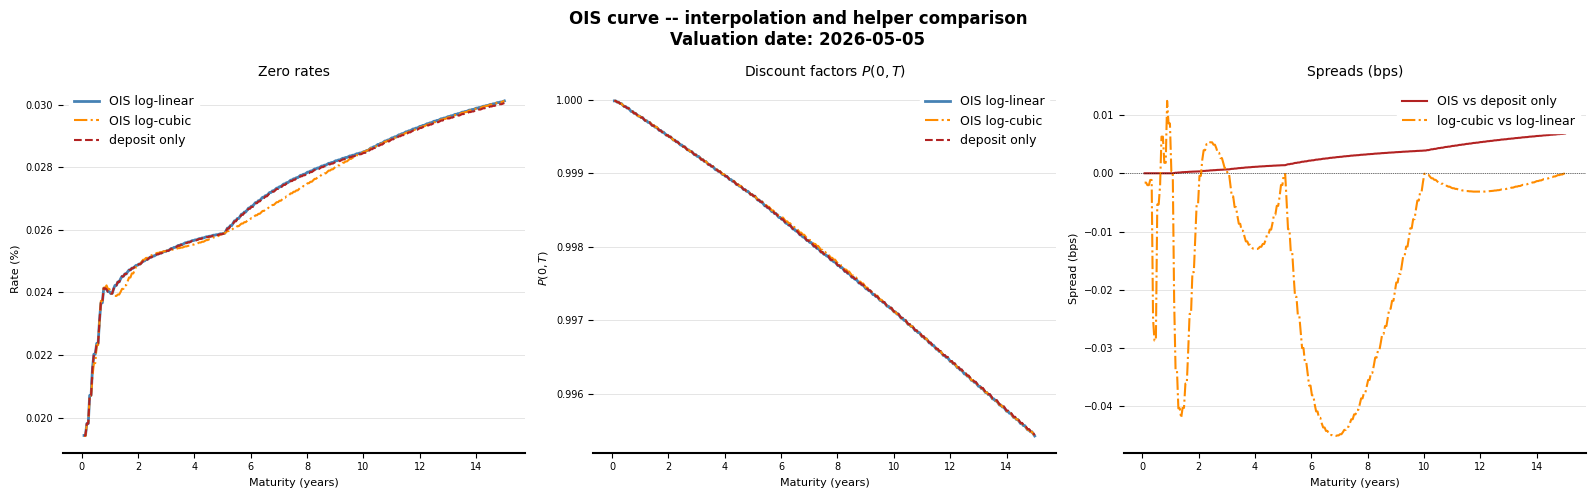

In [7]:
maturities_plot = np.linspace(1/12, 15, 300)

zr_lin_plot, zr_cub_plot, zr_dep_plot = [], [], []
df_lin_plot, df_cub_plot, df_dep_plot = [], [], []

for y in maturities_plot:
    dt = calendar.advance(ql_valuation_date, ql.Period(int(y * 12), ql.Months))
    zr_lin_plot.append(curve_loglin.zeroRate(dt, day_count, ql.Continuous).rate() * 100)
    zr_cub_plot.append(curve_logcub.zeroRate(dt, day_count, ql.Continuous).rate() * 100)
    zr_dep_plot.append(curve_b.zeroRate(dt, day_count, ql.Continuous).rate() * 100)
    df_lin_plot.append(curve_loglin.discount(dt))
    df_cub_plot.append(curve_logcub.discount(dt))
    df_dep_plot.append(curve_b.discount(dt))

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(16, 5))

# zero rates
ax0.plot(maturities_plot, zr_lin_plot, color="steelblue",  linewidth=2,   label="OIS log-linear")
ax0.plot(maturities_plot, zr_cub_plot, color="darkorange", linewidth=1.5, linestyle="-.", label="OIS log-cubic")
ax0.plot(maturities_plot, zr_dep_plot, color="firebrick",  linewidth=1.5, linestyle="--", label="deposit only")
ax0.set_title("Zero rates")
ax0.set_ylabel("Rate (%)")
ax0.set_xlabel("Maturity (years)")
ax0.legend(frameon=True, facecolor="white", framealpha=1, edgecolor="white", fontsize=9)

# discount factors
ax1.plot(maturities_plot, df_lin_plot, color="steelblue",  linewidth=2,   label="OIS log-linear")
ax1.plot(maturities_plot, df_cub_plot, color="darkorange", linewidth=1.5, linestyle="-.", label="OIS log-cubic")
ax1.plot(maturities_plot, df_dep_plot, color="firebrick",  linewidth=1.5, linestyle="--", label="deposit only")
ax1.set_title("Discount factors $P(0,T)$")
ax1.set_ylabel("$P(0,T)$")
ax1.set_xlabel("Maturity (years)")
ax1.legend(frameon=True, facecolor="white", framealpha=1, edgecolor="white", fontsize=9)

# spreads in bps
spread_ois_vs_dep = [(a - b) * 100 for a, b in zip(zr_lin_plot, zr_dep_plot)]
spread_cub_vs_lin = [(a - b) * 100 for a, b in zip(zr_cub_plot, zr_lin_plot)]

ax2.plot(maturities_plot, spread_ois_vs_dep, color="firebrick",  linewidth=1.5,             label="OIS vs deposit only")
ax2.plot(maturities_plot, spread_cub_vs_lin, color="darkorange", linewidth=1.5, linestyle="-.", label="log-cubic vs log-linear")
ax2.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax2.set_title("Spreads (bps)")
ax2.set_ylabel("Spread (bps)")
ax2.set_xlabel("Maturity (years)")
ax2.legend(frameon=True, facecolor="white", framealpha=1, edgecolor="white", fontsize=9)

fig.suptitle(
    f"OIS curve -- interpolation and helper comparison\nValuation date: {ois_valuation_date.date()}",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.show()

### 2.2 Plot discussion: Interpolation comparison

1. zero rate panel: the log-linear curve shows subtle oscillations between pillars, the smooth curve (log-cubic) is clean, and the deposit approximation sits materially below both at long maturities.

2. Log-linear interpolation is monotone in discount factors by construction,
but monotonicity in $P(0,T)$ does not imply monotonicity in forward rates as seen in thrird panel, next.

3. The spread between smooth and log-linear (orange dashed, right panel) is negative between pillar maturities and crosses zero at each node. This is the expected signature of the log-linear interpolation artefact:
- Between pillars the implied instantaneous forward rate overshoots, creating
a visible hump in the zero rate curve (seen in panel 1). The smooth curve (natural log cubic
spline) enforces curvature continuity and eliminates these humps, hence
the correction is always downward between nodes and zero at nodes.

4. The deposit approximation spread (red dashed, right panel) grows
monotonically with maturity; a structural error that compounds as the
single-payment assumption becomes increasingly wrong for longer instruments.
Unlike the interpolation artefact which oscillates around zero, this
divergence has a clear direction and does not self-correct.



## 3. OIS vs NSS government curve -- the spread

The OIS curve discounts at the risk-free rate: compounded ESTR with no
credit or liquidity premium. The NSS government curve reflects euro area
sovereign bond yields, which embed several competing forces:

- **Credit risk**: weighted average of euro area sovereign credit quality,
  including peripheral spreads (Italy, Spain, Portugal), pushing government
  yields above OIS
- **Liquidity and safe-haven demand**: deep secondary markets, LCR/HQLA
  regulatory demand, and structural buying from insurers and pension funds
  compress government yields, pushing them below OIS
- **Bund specialness**: German Bunds, which dominate the AAA basket, trade at a persistent scarcity premium driven by ECB QE holdings and repo market collateral demand, compressing AAA yields below OIS particularly at long maturities

This spread -- government minus OIS zero rate -- is the basis for:

- XVA calculations (CVA uses OIS discounting, bond pricing uses the government curve)
- IRRBB EVE: EBA/RTS/2022/09 prescribes OIS discounting, not the government curve
- IFRS 9 ECL: discount rate selection depends on instrument type and contractual cash flows

NSS AAA date      : 2026-05-05
NSS all issuers   : 2026-05-05


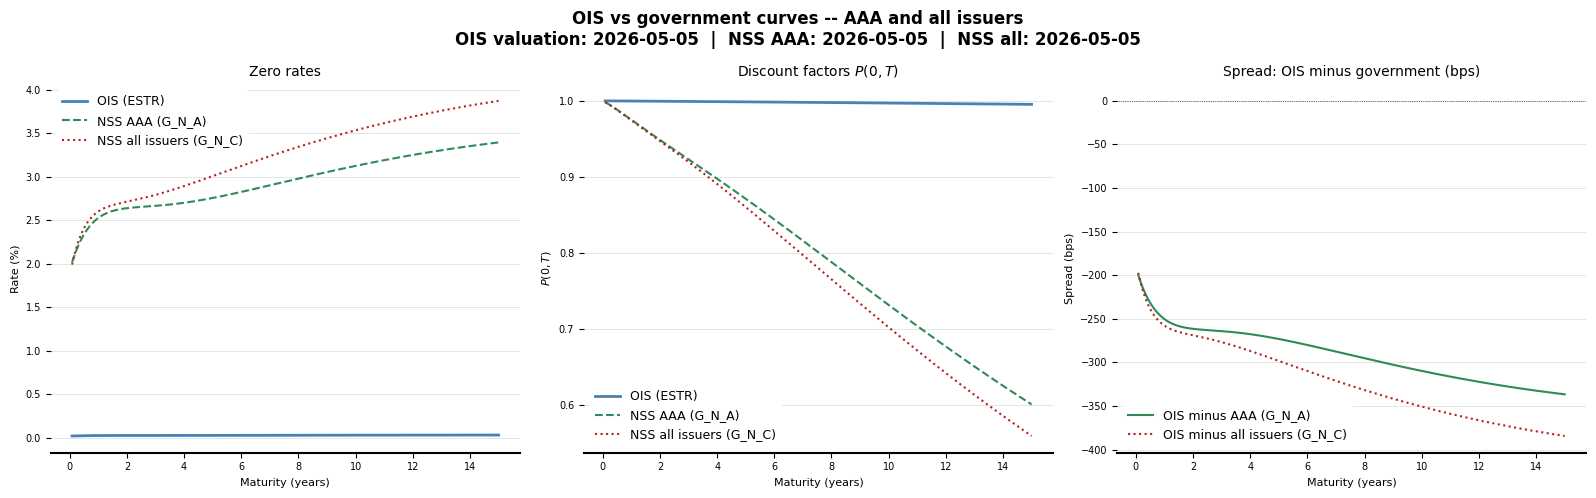

In [8]:
# -----------------------------------------------------------------------
# NSS government curves -- AAA and all issuers at OIS valuation date
# -----------------------------------------------------------------------
def get_params_at_date(params, target_date):
    params.index = pd.to_datetime(params.index)
    if target_date in params.index:
        return params.loc[target_date]
    prior = params[params.index <= target_date]
    p = prior.iloc[-1]
    print(f"NSS parameters not available for {target_date.date()}, "
          f"using {p.name.date()}")
    return p

params_aaa = client.get_nss_parameters(last_n=30, rating="AAA")
params_all = client.get_nss_parameters(last_n=30, rating="ALL")

p_aaa = get_params_at_date(params_aaa, ois_valuation_date)
p_all = get_params_at_date(params_all, ois_valuation_date)

print(f"NSS AAA date      : {p_aaa.name.date()}")
print(f"NSS all issuers   : {p_all.name.date()}")

# -----------------------------------------------------------------------
# NSS zero rate function
# -----------------------------------------------------------------------
def nss_zero_rate(T, beta0, beta1, beta2, beta3, tau1, tau2):
    T = np.asarray(T, dtype=float)
    T = np.where(T < 1e-6, 1e-6, T)
    f1 = (1 - np.exp(-T / tau1)) / (T / tau1)
    f2 = f1 - np.exp(-T / tau1)
    f3 = (1 - np.exp(-T / tau2)) / (T / tau2) - np.exp(-T / tau2)
    return beta0 + beta1 * f1 + beta2 * f2 + beta3 * f3

nss_cols = ["beta0", "beta1", "beta2", "beta3", "tau1", "tau2"]

# -----------------------------------------------------------------------
# compute all curves
# -----------------------------------------------------------------------
maturities_plot = np.linspace(1/12, 15, 300)

zr_ois_plot, zr_aaa_plot, zr_all_plot = [], [], []
df_ois_plot, df_aaa_plot, df_all_plot = [], [], []

for y in maturities_plot:
    dt = calendar.advance(ql_valuation_date, ql.Period(int(y * 12), ql.Months))

    zr_ois = curve_logcub.zeroRate(dt, day_count, ql.Continuous).rate() * 100
    zr_aaa = nss_zero_rate(y, **p_aaa[nss_cols].to_dict())
    zr_all = nss_zero_rate(y, **p_all[nss_cols].to_dict())

    zr_ois_plot.append(zr_ois)
    zr_aaa_plot.append(zr_aaa)
    zr_all_plot.append(zr_all)

    df_ois_plot.append(curve_logcub.discount(dt))
    df_aaa_plot.append(np.exp(-zr_aaa / 100 * y))
    df_all_plot.append(np.exp(-zr_all / 100 * y))

spread_aaa = [(z1 - z2) * 100 for z1, z2 in zip(zr_ois_plot, zr_aaa_plot)]
spread_all = [(z1 - z2) * 100 for z1, z2 in zip(zr_ois_plot, zr_all_plot)]

# -----------------------------------------------------------------------
# plot
# -----------------------------------------------------------------------
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(16, 5))

ax0.plot(maturities_plot, zr_ois_plot, color="steelblue", linewidth=2,   label="OIS (ESTR)")
ax0.plot(maturities_plot, zr_aaa_plot, color="seagreen",  linewidth=1.5, linestyle="--", label="NSS AAA (G_N_A)")
ax0.plot(maturities_plot, zr_all_plot, color="firebrick", linewidth=1.5, linestyle=":",  label="NSS all issuers (G_N_C)")
ax0.set_title("Zero rates")
ax0.set_ylabel("Rate (%)")
ax0.set_xlabel("Maturity (years)")
ax0.legend(frameon=True, facecolor="white", framealpha=1, edgecolor="white", fontsize=9)

ax1.plot(maturities_plot, df_ois_plot, color="steelblue", linewidth=2,   label="OIS (ESTR)")
ax1.plot(maturities_plot, df_aaa_plot, color="seagreen",  linewidth=1.5, linestyle="--", label="NSS AAA (G_N_A)")
ax1.plot(maturities_plot, df_all_plot, color="firebrick", linewidth=1.5, linestyle=":",  label="NSS all issuers (G_N_C)")
ax1.set_title("Discount factors $P(0,T)$")
ax1.set_ylabel("$P(0,T)$")
ax1.set_xlabel("Maturity (years)")
ax1.legend(frameon=True, facecolor="white", framealpha=1, edgecolor="white", fontsize=9)

ax2.plot(maturities_plot, spread_aaa, color="seagreen",  linewidth=1.5,             label="OIS minus AAA (G_N_A)")
ax2.plot(maturities_plot, spread_all, color="firebrick", linewidth=1.5, linestyle=":", label="OIS minus all issuers (G_N_C)")
ax2.axhline(0, color="black", linewidth=0.5, linestyle=":")
ax2.set_title("Spread: OIS minus government (bps)")
ax2.set_ylabel("Spread (bps)")
ax2.set_xlabel("Maturity (years)")
ax2.legend(frameon=True, facecolor="white", framealpha=1, edgecolor="white", fontsize=9)

fig.suptitle(
    f"OIS vs government curves -- AAA and all issuers\n"
    f"OIS valuation: {ois_valuation_date.date()}  |  "
    f"NSS AAA: {p_aaa.name.date()}  |  "
    f"NSS all: {p_all.name.date()}",
    fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.show()

#### Plot discussion:
In the current environment OIS sits below both government curves across all
tenors. This means the credit and peripheral spread component embedded in the
NSS all-issuers curve is currently dominating, with Italian, Spanish and
Portuguese sovereign spreads pushing the weighted average government yield
above the risk-free OIS rate. The AAA curve being also above OIS suggests
that even Bund specialness is not sufficient at current valuations to compress
AAA yields below the ESTR swap rate, which may reflect the reduced ECB balance
sheet following QT and diminished scarcity of high-quality collateral relative
to the 2020-2022 period.

In [8]:
# -----------------------------------------------------------------------
# Persist bootstrapped OIS curve to data/processed/
# Loaded by downstream notebooks via OISCurve.from_processed()
# -----------------------------------------------------------------------
from quant_risk.config import PROCESSED_DIR

pillar_data = {}
for label, bucket in MMSR_OIS_BUCKETS.items():
    dt = calendar.advance(
        ql_valuation_date,
        ql.Period(int(bucket.maturity * 12), ql.Months),
    )
    pillar_data[label] = {
        "years":           bucket.maturity,
        "zero_rate_pct":   curve_logcub.zeroRate(dt, day_count, ql.Continuous).rate() * 100,
        "discount_factor": curve_logcub.discount(dt),
        "valuation_date":  str(ois_valuation_date.date()),
    }

ois_out = pd.DataFrame(pillar_data).T
ois_out.index.name = "maturity"

fname = PROCESSED_DIR / f"ois_curve_{ois_valuation_date.date()}.parquet"
ois_out.to_parquet(fname)
print(f"Saved → {fname}")
print(ois_out[["years", "zero_rate_pct", "discount_factor"]].round(6))

Saved → /Users/mrspatbile/Documents/coding/quant-risk-engine/data/processed/ois_curve_2026-05-05.parquet
             years zero_rate_pct discount_factor
maturity                                        
1M        0.083333      1.939610        0.998331
2M        0.166667      1.975625        0.996603
3M        0.250000      2.064488        0.994738
6M        0.500000      2.219398        0.988721
9M        0.750000      2.393533        0.981817
12M       1.000000      2.368756        0.976270
2Y        2.000000      2.460805        0.951260
3Y        3.000000      2.503751        0.926479
5Y        5.000000      2.559217        0.878263
10Y      10.000000      2.834461        0.750047
10Y+     15.000000      3.012660        0.632172
